# ODRL Tutoral: Policy Evaluation and Enforcement on the Web with ODRL
## ESWC 2026 Tutotial
### Andrea Cimmino, Universidad Politécnica de Madrid (andreajesus.cimmino@upm.es)

**This project has been partially funded by the Madrid Government (Comunidad de Madrid-Spain) under the Multiannual Agreement 2023-2026 with Universidad Politécnica de Madrid in the Line A, Emerging PhD researchers with the project GUIA (M230020126A-AJCA)**

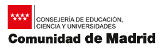
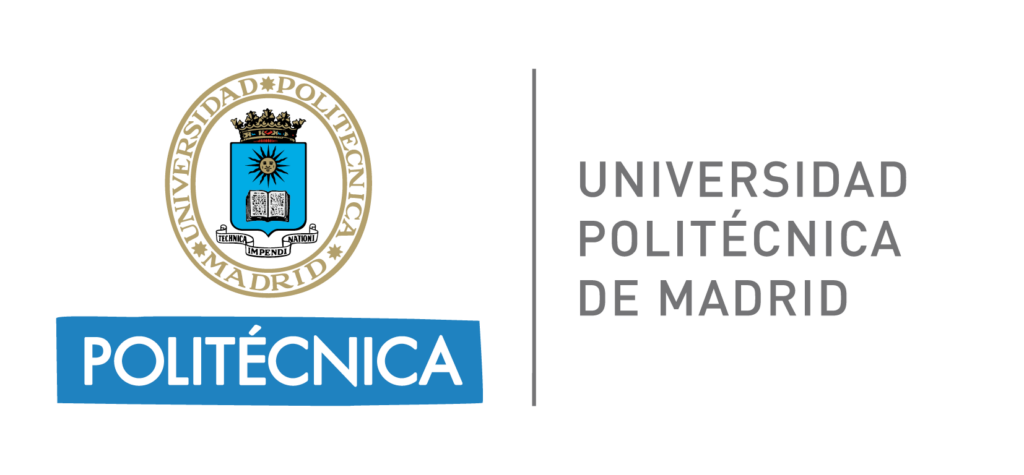

All the following examples are based on the resulting Knowledge Graph of the project GUIA(M230020126A-AJCA)

----

## ODRE Framework (Python implementation)

Welcome to this hands-on notebook on the Python implementation of the [ODRE Framework](https://odre-framework.github.io/odre-framework/).

The ODRE Framework is a policy-based framework designed to support usage control, access governance, and policy enforcement over digital assets and services.

The goal of this notebook is to introduce the main concepts behind the framework and demonstrate how developers can use the Python library to model, evaluate, and enforce data usage policies in real-world applications.

The notebook accompanies the official repositories:

* [ODRE Framework](https://github.com/ODRE-Framework/odre-framework?utm_source=chatgpt.com)
* [ODRE Python Implementation](https://github.com/ODRE-Framework/odre-python?utm_source=chatgpt.com)
* [ODRE Java Implementation](https://github.com/ODRE-Framework/odre-java)




#### What You Will Learn in This Notebook

Throughout this notebook we will progressively explore:

1. Represent ODRL-based policies using JSON-LD.
2. Load and enforce policies with the ODRE Python library.
3. Define policy constraints over users, resources, actions, dates, and times.
4. Register custom operands, operators, and actions associated with URIs.
5. Extend the default Python interpreter with domain-specific functions.
6. Use policy interpolation to inject dynamic values into a policy at runtime.
7. Combine ODRE with external services, such as HTTP resources or Knowledge Graphs.
8. Understand how policy enforcement can be embedded into real data-driven applications.

The notebook is designed as a practical introduction, combining conceptual explanations with executable examples.

----

# 1. Installing and importing libraries

The python implementation is available trough [pypi](https://pypi.org/project/pyodre/)

## 1.1 Installing ODRE library (pyodre)

In [33]:
!pip install pyodre

## 1.2 Importing basic dependencies

In [34]:
from pyodre.odre import ODRE # Importing ODRE

# 2. Quick start: enforcing native ODRL policy

Once the pyodre is installed and imported we proceed enforcing a policy from the ODRL standard. First, the policy is defined:

## 2.1 Enforcing basic policy

In [35]:
policy = """
{
    "@context": "http://www.w3.org/ns/odrl.jsonld",
    "@type": "Set",
    "uid": "urn:professor:my-data",
    "permission": [{
       "target": "https://guia-kg.skai.etsisi.upm.es/resource/andreajesus.cimmino%40upm.es",
       "action": "distribute",
       "constraint": [{
           "leftOperand": "dateTime",
           "operator": "lt",
           "rightOperand":  { "@value": "2040-01-01T09:00:01", "@type": "xsd:dateTime" }
       }]
   }]
}
"""

Finally we enforce the policy

In [36]:
try:
  usage_decision = ODRE().enforce(policy)
  print(usage_decision)
except Exception as exception:
  print(exception)

{'http://www.w3.org/ns/odrl/2/distribute': None}


If the enforcement is positive, i.e., the restrictions on the policy are meet, the pyodre returns a json document with the action as key and a value. Whether the value is None it means the responsible for performing the action is whoever requested the action. Instead, if the value is not none it will display the result of perfoming the action, pyodre will do it for you.

**In this case since the result is `{'http://www.w3.org/ns/odrl/2/read': None}` it means pyodre will not distribute the document but whoever requested to distribute it is allowed to do so.**

On the contraty, if we change the `operator` of the policy so the restriction is never meet and the policy is enforced:

In [37]:
policy = """
{
    "@context": "http://www.w3.org/ns/odrl.jsonld",
    "@type": "Set",
    "uid": "urn:professor:my-data",
    "permission": [{
       "target": "https://guia-kg.skai.etsisi.upm.es/resource/andreajesus.cimmino%40upm.es",
       "action": "distribute",
       "constraint": [{
           "leftOperand": "dateTime",
           "operator": "gt",
           "rightOperand":  { "@value": "2040-01-01T09:00:01", "@type": "xsd:dateTime" }
       }]
   }]
}
"""

try:
  usage_decision = ODRE().enforce(policy)
  print(usage_decision)
except Exception as exception:
  print(exception)

{}


**It can be observed that the ouput of the evaluation is `{}` meaning the conditions to distribute the document are not meet.**

## 2.2 ODRL native supported features

### ODRL operantors

| Operators | Implementation status | # |
|--|--| -- |
| [eq](https://www.w3.org/TR/odrl-vocab/#term-eq) | supported  | &check; |
| [gt](https://www.w3.org/TR/odrl-vocab/#term-gt)  | supported  | &check; |
| [gteq](https://www.w3.org/TR/odrl-vocab/#term-gteq) | supported  | &check; |
| [lt](https://www.w3.org/TR/odrl-vocab/#term-lt)  | supported  | &check; |
| [lteq](https://www.w3.org/TR/odrl-vocab/#term-lteq)  | supported  | &check; |
| [neq](https://www.w3.org/TR/odrl-vocab/#term-neq)  | supported  | &check; |

### ODRL operands
* The available implemented [Left Operands](https://www.w3.org/TR/odrl-vocab/#term-LeftOperand) from those specified in the [ODRL Vocabulary & Expression 2.2](https://www.w3.org/TR/odrl-vocab/) are the following:

| Left Operands                                                                               | Implementation status | # |
|---------------------------------------------------------------------------------------------|--| -- |
| [dateTime](https://www.w3.org/TR/odrl-vocab/#term-dateTime)                                 | supported | &check; |



----

# 3. Policy interpolation (policy template and variables)

ODRE, either `pyodre` or `odre-java`, rely on the concept of `interpolation` to allow policies to work with dynamic data. The `interpolation` concept is close to the State of the World and Evaluation Request, however it offers also additional benefits.



## 3.1 Variable interpolation

The policies may have elements that are unknown during the policy definition and that will be provided on-the-fly during the enforcement task. The variables are introduced in the policies between the symbols `{{` and ``}}``.

The following policy displays how to achieve the same functionality as the previous policies, i.e., compare the current datetime with a threshold, but instead of using an operator the datetime is passed as a variable.

In [38]:
policy = """{
    "@context": "http://www.w3.org/ns/odrl.jsonld",
    "@type": "Set",
    "uid": "urn:professor:my-data",
    "permission": [{
       "target": "https://guia-kg.skai.etsisi.upm.es/resource/andreajesus.cimmino%40upm.es",
       "action": "distribute",
       "constraint": [{
           "leftOperand": { "@value": "{{datetime_variable}}", "@type": "xsd:dateTime" },
           "operator": "lt",
           "rightOperand":  { "@value": "2040-01-01T09:00:01", "@type": "xsd:dateTime" }
       }]
   }]
}
"""

# The variable in the policy and in the interopolation
# json must be called in the same way
interpolations = { "datetime_variable" : "2026-05-10T13:00:00"}

try:
  usage_decision = ODRE().enforce(policy, interpolations=interpolations)
  print(usage_decision)
except Exception as exception:
  print(exception)

{'http://www.w3.org/ns/odrl/2/distribute': None}


Although for datetime it may seem introducing variables is not useful since this information is known by the system, image a scenario where the policy depends on a token which is unknown beforehand because a user must provide as in the following policy:

In [39]:
policy = """{
    "@context": "http://www.w3.org/ns/odrl.jsonld",
    "@type": "Set",
    "uid": "urn:professor:my-data",
    "permission": [{
       "target": "https://guia-kg.skai.etsisi.upm.es/resource/andreajesus.cimmino%40upm.es",
       "action": "distribute",
       "constraint": [{
           "leftOperand": { "@value": "{{token_variable}}", "@type": "xsd:string" },
           "operator": "eq",
           "rightOperand":  { "@value": "9d233b61-d406-4bf9-a9b6-6967a96e3c9b", "@type": "xsd:string" }
       }]
   }]
}
"""

# The variable in the policy and in the interopolation
# json must be called in the same way
interpolations = { "token_variable" : "9d233b61-d406-4bf9-a9b6-6967a96e3c9b"}

try:
  usage_decision = ODRE().enforce(policy, interpolations=interpolations)
  print(usage_decision)
except Exception as exception:
  print(exception)

{'http://www.w3.org/ns/odrl/2/distribute': None}


However, as displayed in the policy it requires the `rightOperand` to have hardcoded the access token which may lead to privacy leakage.

## 3.2 Function interpolation

To tackle the previous problem, another thing that can be interpolated are the functions. For instance, for the previous example the `rightOperand` may rely on an interpolated function for preventing data privacy leak.

In [40]:
policy = """{
    "@context": "http://www.w3.org/ns/odrl.jsonld",
    "@type": "Set",
    "uid": "urn:professor:my-data",
    "permission": [{
       "target": "https://guia-kg.skai.etsisi.upm.es/resource/andreajesus.cimmino%40upm.es",
       "action": "distribute",
       "constraint": [{
           "leftOperand": { "@value": "{{token_variable}}", "@type": "xsd:string" },
           "operator": "eq",
           "rightOperand":  { "@value": "{{token_exist_fn(token_variable)}}", "@type": "xsd:string" }
       }]
   }]
}
"""

def token_exist_fn(token):
  print("function 'token_exist_fn' called with parameter: ", token)
  allowed_tokens = ["9d233b61-d406-4bf9-a9b6-6967a96e3c9b", "9ed265d1-0671-45a1-ad9c-3660046a212a", "a7b3ebc6-83c5-4741-ac12-961f169694e6"]
  for allowed_token in allowed_tokens:
    if token in allowed_tokens:
      return token
  return "" # No token is ouput

# The variable and function in the policy and in the interopolation
# json must be called in the same way
interpolations = {
    "token_variable" : "9d233b61-d406-4bf9-a9b6-6967a96e3c9b",
    "token_exist_fn" : token_exist_fn
    }

try:
  usage_decision = ODRE().enforce(policy, interpolations=interpolations)
  print(usage_decision)
except Exception as exception:
  print(exception)

function 'token_exist_fn' called with parameter:  9d233b61-d406-4bf9-a9b6-6967a96e3c9b
{'http://www.w3.org/ns/odrl/2/distribute': None}


# 4. Extending ODRL native features supported

Many times, a user extends the ontology of ODRL with new terms and wants those term to behave in a certain way when evaluating a policy. For these cases ODRE is designed for allowing users to bound an ontological term to a python function.

The functions to be bounded are dynamically read from the memory, so as far as they exist in the script ODRE discovers them.


## 4.1 Extending ODRL `operands`

In this case assuning there in an ontology that extends ODRL `http://eswc.tutorial/ordl#` and has defined the term `operand_time` that returns the current time. We are going to setup the ODRE engine to:
  1. Bound the ontological term to a function
  2. Setup the namespace `http://eswc.tutorial/ordl#` so ODRE will be able to discover functions bounded to terms in that ontology

In [41]:
from pyodre.odre import PythonInterpreter
import pyodre.python_functions as odre_functions
from datetime import datetime, timezone

'''
  1. Bound the ontological term to a function

  In order to bind a function to a term in an ontology the function name must
  meet 2 rules. It has to be defined under a prefix, in this case fn_ and the
  rest of the function's name must be the same as the ontological term. In this
  case operand_time. The result is that this function must be called
  'fn_operant_time()'. Also, since ODRL does not support anyhow arguments for
  the operands these functions must be defined with no paremeters

'''

def fn_operand_time():
    return datetime.strptime(datetime.now().strftime("%H:%M:%S"), "%H:%M:%S")


'''
  2. Setup a namespace so ODRE can discover functions linked to its terms

  To achieve this behaviour a user must extend the class 'PythonInterpreter'.
  In this case we defined the 'CustomPythonInterpreter'. In this new class
  it is important to register the prefix of the function and the URI of
  the ontology (A). This allows ODRE to find terms in the ontology as python
  functions.  Finally, in order for ODRE to dynamically invoke the functions
  the environment must be updated as shown in the method 'evaluate' (B).

'''

class CustomPythonInterpreter(PythonInterpreter):

    def __init__(self):
        super().__init__()
        # (A) linking function prefix to ontology prefix
        self.add_prefix_mapping("fn_", "http://eswc.tutorial/ordl#")

    # (B) updating python environment to invoke local functions
    def evaluate(self, expression):
        env = vars(odre_functions).copy()  # copies odrl native definitions: odrl_lt, cast_time, etc.
        env.update({
            "fn_operand_time": fn_operand_time
        })
        return eval(expression, env)

interpreter = CustomPythonInterpreter()
print(interpreter.get_prefixes_mappings())

{'odrl_': 'http://www.w3.org/ns/odrl/2/', 'cast_': 'http://www.w3.org/2001/XMLSchema#', 'time_': 'https://w3id.org/def/odre-time#', 'demo_': 'https://w3id.org/def/odre-demo#', 'fn_': 'http://eswc.tutorial/ordl#'}


With the previous code, now a policy that uses the term `<http://eswc.tutorial/ordl#operand_time>` can be defined and the ODRE engine invoked. However, before invoking the engine the new interpreter must be setup

In [42]:

policy = """{
    "@context": [
      "http://www.w3.org/ns/odrl.jsonld",
      {
        "tutorial" : "http://eswc.tutorial/ordl#"
      }
    ],
    "@type": "Set",
    "uid": "urn:professor:my-data",
    "permission": [{
       "target": "https://guia-kg.skai.etsisi.upm.es/resource/andreajesus.cimmino%40upm.es",
       "action": "distribute",
       "constraint": [{
           "leftOperand": "tutorial:operand_time",
           "operator": "lt",
           "rightOperand":  { "@value": "20:00:01", "@type": "xsd:time" }
       }]
   }]
}
"""

try:
  odre = ODRE()
  # Setting up the interpreter
  odre.set_interpreter(interpreter)
  usage_decision = odre.enforce(policy)
  print(usage_decision)
except Exception as exception:
  print(exception)

{'http://www.w3.org/ns/odrl/2/distribute': None}


**Now we can play with the time to see wheter we are allows to `distribute`or not the document**

## 4.2 Extending ODRL operators

As before, now we are going to bound a function to the ontological term `operator_between` that returns true if the current time is between the left operand time and the right operand time.

In [43]:
from pyodre.odre import PythonInterpreter
import pyodre.python_functions as odre_functions
from datetime import datetime, timezone

'''
  1. Bound the ontological term to a function
'''

def fn_operand_time():
  return datetime.strptime(datetime.now().strftime("%H:%M:%S"), "%H:%M:%S")

# Operators always receive 2 parametres, left and right operand
# check that since function is linked to a term from the same ontology
# we use the same function prefix fn_
def fn_operator_between(operand1, operand2):
  now = datetime.now().time()
  operand1 = operand1.time()
  operand2 = operand2.time()
  print(">", now, " ", operand1, " ", operand2)
  if operand1 <= operand2:
    return operand1 <= now <= operand2
  else:
    return now >= operand1 or now <= operand2

'''
  2. Setup a namespace so ODRE can discover functions linked to its terms

'''

class CustomPythonInterpreter(PythonInterpreter):

    def __init__(self):
        super().__init__()
        # (A) linking function prefix to ontology prefix
        self.add_prefix_mapping("fn_", "http://eswc.tutorial/ordl#")

    # (B) updating python environment to invoke local functions
    def evaluate(self, expression):
        env = vars(odre_functions).copy()  # copies odrl native definitions: odrl_lt, cast_time, etc.
        env.update({
            "fn_operand_time": fn_operand_time,
            "fn_operator_between" : fn_operator_between
        })
        return eval(expression, env)

interpreter = CustomPythonInterpreter()
print(interpreter.get_prefixes_mappings())

{'odrl_': 'http://www.w3.org/ns/odrl/2/', 'cast_': 'http://www.w3.org/2001/XMLSchema#', 'time_': 'https://w3id.org/def/odre-time#', 'demo_': 'https://w3id.org/def/odre-demo#', 'fn_': 'http://eswc.tutorial/ordl#'}


In [44]:

policy = """{
    "@context": [
      "http://www.w3.org/ns/odrl.jsonld",
      {
        "tutorial" : "http://eswc.tutorial/ordl#"
      }
    ],
    "@type": "Set",
    "uid": "urn:professor:my-data",
    "permission": [{
       "target": "https://guia-kg.skai.etsisi.upm.es/resource/andreajesus.cimmino%40upm.es",
       "action": "distribute",
       "constraint": [{
           "leftOperand": "tutorial:operand_time",
           "operator": "lt",
           "rightOperand":  { "@value": "20:00:01", "@type": "xsd:time" }
       },{
           "leftOperand": { "@value": "08:00:01", "@type": "xsd:time" },
           "operator": "tutorial:operator_between",
           "rightOperand":  { "@value": "23:59:00", "@type": "xsd:time" }
       }]
   }]
}
"""

try:
  odre = ODRE()
  # Setting up the interpreter
  odre.set_interpreter(interpreter)
  usage_decision = odre.enforce(policy)
  print(usage_decision)
except Exception as exception:
  print(exception)

> 09:30:28.453024   08:00:01   23:59:00
{'http://www.w3.org/ns/odrl/2/distribute': None}


## 4.3 Extending ODRL actions (description + behaviour) I





Similarly as shown before, instead of operands ODRE allows to grant behaviour to the actions defined in the policy. Following this approach now is ODRE who will perform the action instead of delegating the action to be performed by a user.

This approach is interesting since the system is the one interacting with third-party systems.

In the following example an actionis going to be created that directly returns the document to be read by extending the interpreter. Note that the action is part of the ontology extension, i.e., a term from the ontology.

In [45]:
from pyodre.odre import PythonInterpreter
import pyodre.python_functions as odre_functions
from datetime import datetime, timezone
import requests


'''
  1. Bound the ontological term to a function
'''

def fn_operand_time():
  return datetime.strptime(datetime.now().strftime("%H:%M:%S"), "%H:%M:%S")

def fn_operator_between(operand1, operand2):
  now = datetime.now().time()
  operand1 = operand1.time()
  operand2 = operand2.time()
  print(">", now, " ", operand1, " ", operand2)
  if operand1 <= operand2:
    return operand1 <= now <= operand2
  else:
    return now >= operand1 or now <= operand2

# Action that reads static link
def fn_read_personal_document():
  print("action!")
  link = "https://guia-kg.skai.etsisi.upm.es/resource/andreajesus.cimmino%40upm.es"
  return requests.get(link).text


'''
  2. Setup a namespace so ODRE can discover functions linked to its terms

'''

class CustomPythonInterpreter(PythonInterpreter):

    def __init__(self):
        super().__init__()
        # (A) linking function prefix to ontology prefix
        self.add_prefix_mapping("fn_", "http://eswc.tutorial/ordl#")

    # (B) updating python environment to invoke local functions
    def evaluate(self, expression):
        env = vars(odre_functions).copy()  # copies odrl native definitions: odrl_lt, cast_time, etc.
        env.update({
            "fn_operand_time": fn_operand_time,
            "fn_operator_between" : fn_operator_between,
            "fn_read_personal_document" : fn_read_personal_document # Updating env
        })
        return eval(expression, env)

    # (C) here we extend the interpreter with the new native supported actions
    def supports(self, action):
        interpretable_action = None

        for prefix_mapping, uri_mapping in self.get_prefixes_mappings().items():
            if uri_mapping in action:
                interpretable_action = action.replace(uri_mapping, prefix_mapping)
                break

        if interpretable_action in {
            "fn_read_personal_document"
        }:
            return interpretable_action + "()"

        return super().supports(action)

interpreter = CustomPythonInterpreter()
print(interpreter.get_prefixes_mappings())

{'odrl_': 'http://www.w3.org/ns/odrl/2/', 'cast_': 'http://www.w3.org/2001/XMLSchema#', 'time_': 'https://w3id.org/def/odre-time#', 'demo_': 'https://w3id.org/def/odre-demo#', 'fn_': 'http://eswc.tutorial/ordl#'}


In [46]:
policy = """{
    "@context": [
      "http://www.w3.org/ns/odrl.jsonld",
      {
        "tutorial" : "http://eswc.tutorial/ordl#"
      }
    ],
    "@type": "Set",
    "uid": "urn:professor:my-data",
    "permission": [{
       "target": "https://guia-kg.skai.etsisi.upm.es/resource/andreajesus.cimmino%40upm.es",
       "action": "tutorial:read_personal_document",
       "constraint": [{
           "leftOperand": "tutorial:operand_time",
           "operator": "lt",
           "rightOperand":  { "@value": "20:00:01", "@type": "xsd:time" }
       },{
           "leftOperand": { "@value": "08:00:01", "@type": "xsd:time" },
           "operator": "tutorial:operator_between",
           "rightOperand":  { "@value": "23:59:00", "@type": "xsd:time" }
       }]
   }]
}
"""

try:
  odre = ODRE()
  # Setting up the interpreter
  odre.set_interpreter(interpreter)
  usage_decision = odre.enforce(policy)
  print(usage_decision)
except Exception as exception:
  print(exception)

> 09:30:28.579695   08:00:01   23:59:00
action!
{'http://eswc.tutorial/ordl#read_personal_document': '<https://guia-kg.skai.etsisi.upm.es/resource/615000306/2025-26> <https://schema.org/instructor> <https://guia-kg.skai.etsisi.upm.es/resource/andreajesus.cimmino%40upm.es> .\n<https://guia-kg.skai.etsisi.upm.es/resource/615000347/2025-26> <https://schema.org/instructor> <https://guia-kg.skai.etsisi.upm.es/resource/andreajesus.cimmino%40upm.es> .\n<https://guia-kg.skai.etsisi.upm.es/resource/andreajesus.cimmino%40upm.es> <https://schema.org/email> "andreajesus.cimmino@upm.es" .\n<https://guia-kg.skai.etsisi.upm.es/resource/andreajesus.cimmino%40upm.es> <https://schema.org/name> "Cimmino Arriaga, Andrea Jesus" .\n<https://guia-kg.skai.etsisi.upm.es/resource/andreajesus.cimmino%40upm.es> <https://guia.org/tutorshipsSchedule> "solicitar tutoria vía email"@es .\n<https://guia-kg.skai.etsisi.upm.es/resource/andreajesus.cimmino%40upm.es> <https://guia.org/tutorshipsSchedule> "Publicadas en la 

## 4.4 Extending ODRL actions (description + behaviour) II





Actions can not be dynamically setup with parameters or variables and therefore their behaviour may seem static. In this case the action always reads the same link `https://guia-kg.skai.etsisi.upm.es/resource/andreajesus.cimmino%40upm.es`.  However, since ODRE has a strong programmatic component with a few tweaks we can transform the previous example into a higly dynamic scenario.

To showcase the example, let's define a native operator `anyOf` like the one in ODRL. Also, let's rely on a global variable named `CURRENT_USER_ID` that we will use to pass the user id among the different functions (either native extensions or interopolation functions).

In [47]:
CURRENT_USER_ID = None

In [48]:
from pyodre.odre import PythonInterpreter
import pyodre.python_functions as odre_functions
from datetime import datetime, timezone
import requests


'''
  1. Bound the ontological term to a function
'''

def fn_operand_time():
  return datetime.strptime(datetime.now().strftime("%H:%M:%S"), "%H:%M:%S")

def fn_operator_between(operand1, operand2):
  now = datetime.now().time()
  operand1 = operand1.time()
  operand2 = operand2.time()
  print(">", now, " ", operand1, " ", operand2)
  if operand1 <= operand2:
    return operand1 <= now <= operand2
  else:
    return now >= operand1 or now <= operand2

# >> Action that reads DYNAMIC link
def fn_read_personal_document():
  print("action!")
  link = "https://guia-kg.skai.etsisi.upm.es/resource/"+CURRENT_USER_ID
  return requests.get(link).text


def fn_anyOf(operand1, operand2):
  id = str(operand1)
  allowed_ids = eval(operand2)
  print("fn_anyOf>", id," ", allowed_ids)
  return id in allowed_ids


'''
  2. Setup a namespace so ODRE can discover functions linked to its terms

'''

class CustomPythonInterpreter(PythonInterpreter):

    def __init__(self):
        super().__init__()
        # (A) linking function prefix to ontology prefix
        self.add_prefix_mapping("fn_", "http://eswc.tutorial/ordl#")

    # (B) updating python environment to invoke local functions
    def evaluate(self, expression):
        env = vars(odre_functions).copy()  # copies odrl native definitions: odrl_lt, cast_time, etc.
        env.update({
            "fn_operand_time": fn_operand_time,
            "fn_operator_between" : fn_operator_between,
            "fn_read_personal_document" : fn_read_personal_document,
            "fn_anyOf" : fn_anyOf # Updating env
        })
        return eval(expression, env)

    # (C) here we extend the interpreter with the new native supported actions
    def supports(self, action):
        interpretable_action = None

        for prefix_mapping, uri_mapping in self.get_prefixes_mappings().items():
            if uri_mapping in action:
                interpretable_action = action.replace(uri_mapping, prefix_mapping)
                break

        if interpretable_action in {
            "fn_read_personal_document"
        }:
            return interpretable_action + "()"

        return super().supports(action)

interpreter = CustomPythonInterpreter()
print(interpreter.get_prefixes_mappings())

{'odrl_': 'http://www.w3.org/ns/odrl/2/', 'cast_': 'http://www.w3.org/2001/XMLSchema#', 'time_': 'https://w3id.org/def/odre-time#', 'demo_': 'https://w3id.org/def/odre-demo#', 'fn_': 'http://eswc.tutorial/ordl#'}


Following let's define a complex policy that allows any user with a `user_id` to get their data directly (ODRE will retrieve it) if that id is allowed and also if the current time is between two thresholds (like the working time). Notice that with all what we have learnt the thresholds could be dynamically fetched based on the `user_id`.

They key element in the following excerpt of code is the variable `CURRENT_USER_ID` previously defined.

In [52]:

policy = """{
    "@context": [
      "http://www.w3.org/ns/odrl.jsonld",
      {
        "tutorial" : "http://eswc.tutorial/ordl#"
      }
    ],
    "@type": "Set",
    "uid": "urn:professor:my-data",
    "permission": [{
       "target": "https://guia-kg.skai.etsisi.upm.es/resource/{{user_id}}",
       "action": "tutorial:read_personal_document",
       "constraint": [{
           "leftOperand": { "@value": "{{user_id}}", "@type": "xsd:string" },
           "operator": "tutorial:anyOf",
           "rightOperand":  { "@value": "{{allowed_users()}}", "@type": "xsd:string" }
       },{
           "leftOperand": { "@value": "08:00:01", "@type": "xsd:time" },
           "operator": "tutorial:operator_between",
           "rightOperand":  { "@value": "23:59:00", "@type": "xsd:time" }
       }]
   }]
}
"""

CURRENT_USER_ID = 'andreajesus.cimmino%40upm.es'


def allowed_users():
  print("allowed_users")
  return ['andreajesus.cimmino%40upm.es', 'b.deabajo%40upm.es', 'm.deabreu%40upm.es']


interpolations = {
    'user_id' : CURRENT_USER_ID,
    'allowed_users' : allowed_users
}


try:
  odre = ODRE()
  # Setting up the interpreter
  odre.set_interpreter(interpreter)
  usage_decision = odre.enforce(policy, interpolations=interpolations)
  print(usage_decision)
except Exception as exception:
  print(exception)

allowed_users
fn_anyOf> b.deabajo%40upm.es   ['andreajesus.cimmino%40upm.es', 'b.deabajo%40upm.es', 'm.deabreu%40upm.es']
> 09:33:25.133065   08:00:01   23:59:00
action!
{'http://eswc.tutorial/ordl#read_personal_document': '<https://guia-kg.skai.etsisi.upm.es/resource/b.deabajo%40upm.es> <https://schema.org/email> "b.deabajo@upm.es" .\n<https://guia-kg.skai.etsisi.upm.es/resource/b.deabajo%40upm.es> <https://schema.org/name> "Abajo Castrillo, Begoña De" .\n<https://guia-kg.skai.etsisi.upm.es/resource/b.deabajo%40upm.es> <https://guia.org/tutorshipsSchedule> "El horario de tutorías será a demanda en el horario acordado entre la profesora y el alumnado"@es .\n<https://guia-kg.skai.etsisi.upm.es/resource/b.deabajo%40upm.es> <https://guia.org/tutorshipsSchedule> "Sin horario. El horario de tutorías será a demanda en el horario acordado entre profesorado y alumnado"@es .\n<https://guia-kg.skai.etsisi.upm.es/resource/b.deabajo%40upm.es> <https://guia.org/office> "En el aula"@es .\n<https://g

# 5. Conclusions

In this notebook, we have seen how the ODRE Python implementation can be used to enforce usage policies expressed in JSON-LD and inspired by the ODRL model.

We started from a simple policy and progressively extended it with more dynamic behaviour. In particular, we have seen how to define policies with permissions, targets, actions, and constraints; how to evaluate those policies using the ODRE engine; and how to extend the interpreter with custom Python functions associated with specific URIs.

We also explored how ODRE can support domain-specific policy logic by registering custom operands, operators, and actions. This makes it possible to connect high-level policy descriptions with executable behaviour, such as checking temporal constraints, validating users, or retrieving protected resources from external services.

Finally, we introduced policy interpolation as a mechanism for making policies dynamic. Through interpolation, values can be injected into a policy at runtime, allowing the same policy template to be reused in different execution contexts.

**This notebook only covers a subset of what can be done**. Since the interpolation mechanism is based on Jinja syntax, policies can also include more advanced templating features. **For example, it is possible to embed function calls directly inside the policy template, generate policy fragments conditionally using `if` / `else` blocks, or create repeated structures using `for` loops.**

These features open the door to **more flexible policy generation patterns, where policies are not only static documents, but dynamic templates that can adapt to the user, the resource, the execution context, or the application logic.**